In [1]:
import json
import pandas as pd

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"

# Fast: get columns from only the first JSONL row (no full load)
with open(file_path, "r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())
columns = list(first_row.keys())
print("Columns:", columns)

# Process in chunks to avoid RAM explosion
chunk_size = 100_000  # tune this (e.g., 20k, 50k, 100k)

for i, chunk in enumerate(pd.read_json(file_path, lines=True, chunksize=chunk_size)):
    # Optional memory reduction per chunk
    for c in chunk.select_dtypes(include=["int64"]).columns:
        chunk[c] = pd.to_numeric(chunk[c], downcast="integer")
    for c in chunk.select_dtypes(include=["float64"]).columns:
        chunk[c] = pd.to_numeric(chunk[c], downcast="float")

    # Do your analysis here (important: don't store all chunks)
    # example:
    # print(chunk["label"].value_counts())

    print(f"Processed chunk {i+1} with {len(chunk)} rows")

Columns: ['index', 'Label', 'Confidence', 'Reasoning', '__row_index', 'self_text', 'comment_id', 'score', 'author_name', 'controversiality', 'created_time', 'subreddit', 'post_id', 'parent_id', 'permalink', 'post_title', 'post_score', 'post_upvote_ratio', 'post_created_time', 'num_comments']
Processed chunk 1 with 100000 rows
Processed chunk 2 with 100000 rows
Processed chunk 3 with 100000 rows


KeyboardInterrupt: 

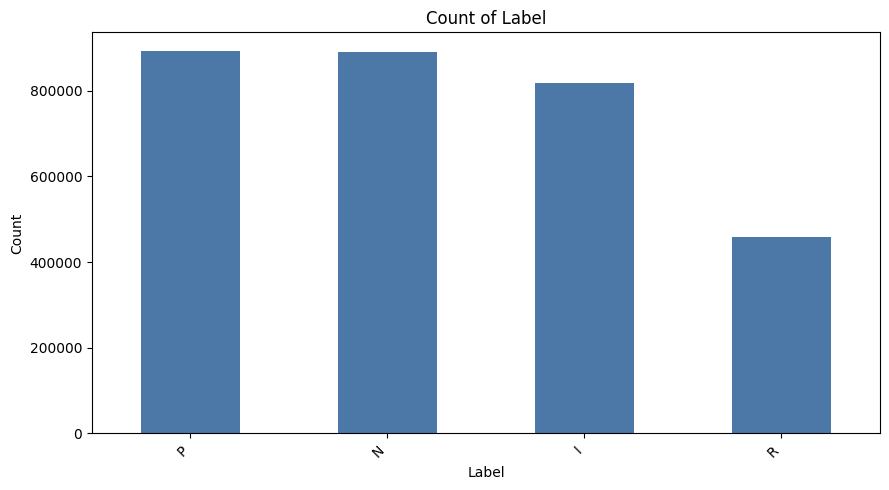

Label
P    891857
N    890021
I    818027
R    457810
dtype: int64


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"
chunk_size = 100_000

# Detect correct label column name from first row (e.g., Label vs label)
with open(file_path, "r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())

label_col = "Label" if "Label" in first_row else "label"

label_counts = pd.Series(dtype="int64")

for chunk in pd.read_json(file_path, lines=True, chunksize=chunk_size):
    if label_col not in chunk.columns:
        continue

    chunk_counts = (
        chunk[label_col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
        .value_counts()
    )
    label_counts = label_counts.add(chunk_counts, fill_value=0)

label_counts = label_counts.sort_values(ascending=False).astype(int)

plt.figure(figsize=(9, 5))
label_counts.plot(kind="bar", color="#4C78A8")
plt.title("Count of Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(label_counts)

In [6]:
import json
import pandas as pd

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"
chunk_size = 100_000

with open(file_path, "r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())

date_col = "created_time" if "created_time" in first_row else "post_created_time"

subreddits = set()
global_min_dt = None
global_max_dt = None

def parse_chunk_dates(series: pd.Series) -> pd.Series:
    raw = series.dropna()

    # Numeric path (unix epoch with unknown unit)
    num = pd.to_numeric(raw, errors="coerce")
    num = num.dropna()

    dt_parts = []

    if not num.empty:
        med = num.median()
        if med > 1e17:
            unit = "ns"
        elif med > 1e14:
            unit = "us"
        elif med > 1e11:
            unit = "ms"
        else:
            unit = "s"

        dt_num = pd.to_datetime(num, unit=unit, utc=True, errors="coerce")
        dt_parts.append(dt_num)

    # String/datetime path (if any)
    non_num = raw[pd.to_numeric(raw, errors="coerce").isna()]
    if not non_num.empty:
        dt_str = pd.to_datetime(non_num, utc=True, errors="coerce")
        dt_parts.append(dt_str)

    if not dt_parts:
        return pd.Series(dtype="datetime64[ns, UTC]")

    dt = pd.concat(dt_parts, ignore_index=True).dropna()

    # Keep only realistic Reddit-era timestamps
    lower = pd.Timestamp("2005-01-01", tz="UTC")
    upper = pd.Timestamp.utcnow() + pd.Timedelta(days=1)
    dt = dt[(dt >= lower) & (dt <= upper)]

    return dt

for chunk in pd.read_json(file_path, lines=True, chunksize=chunk_size):
    if "subreddit" in chunk.columns:
        subs = chunk["subreddit"].dropna().astype(str).str.strip()
        subs = subs[subs != ""]
        subreddits.update(subs.unique().tolist())

    if date_col in chunk.columns:
        dt = parse_chunk_dates(chunk[date_col])
        if not dt.empty:
            cmin = dt.min()
            cmax = dt.max()
            global_min_dt = cmin if global_min_dt is None else min(global_min_dt, cmin)
            global_max_dt = cmax if global_max_dt is None else max(global_max_dt, cmax)

print(f"Unique subreddits ({len(subreddits)}):")
for s in sorted(subreddits):
    print(s)

if global_min_dt is not None and global_max_dt is not None:
    print(f"\nDate range ({date_col}, UTC): {global_min_dt} to {global_max_dt}")
else:
    print(f"\nCould not compute date range from '{date_col}'.")

Unique subreddits (5):
AskMiddleEast
Israel
IsraelPalestine
IsrealPalestineWar_23
Palestine

Date range (created_time, UTC): 2023-08-07 00:50:40+00:00 to 2024-05-07 23:59:58+00:00


Rows loaded: 3,057,715
Columns available: ['Label', 'Confidence', 'Reasoning', 'created_time', 'post_created_time', 'subreddit', 'self_text', 'comment_id', 'score', 'author_name', 'controversiality', 'post_id', 'parent_id', 'permalink', 'post_title', 'post_score', 'post_upvote_ratio', 'num_comments', 'label_norm', 'subreddit_norm', 'confidence_num', 'created_dt', 'post_created_dt', 'self_text_len', 'reasoning_len', 'parent_type', 'is_controversial']


,Label,Confidence,Reasoning,created_time,post_created_time,subreddit,self_text,comment_id,score,author_name,...,num_comments,label_norm,subreddit_norm,confidence_num,created_dt,post_created_dt,self_text_len,reasoning_len,parent_type,is_controversial
0,R,High,The post is about the new Twitter logo and has...,2023-08-07 02:51:41,2023-08-07 02:45:52,AskMiddleEast,It's just to show their background and in this...,jv42f8z,3,Heliopolis1992,...,8,R,AskMiddleEast,NaN,2023-08-07 02:51:41+00:00,2023-08-07 02:45:52+00:00,139,87,reply_to_post,0
1,R,High,The post is about the new Twitter logo and has...,2023-08-07 03:04:34,2023-08-07 02:45:52,AskMiddleEast,That’s what I thought. Thanks for explaining t...,jv43wr1,3,ASecularBuddhist,...,8,R,AskMiddleEast,NaN,2023-08-07 03:04:34+00:00,2023-08-07 02:45:52+00:00,58,87,reply_to_comment,0
2,R,High,The post is about the new Twitter logo and has...,2023-08-07 03:19:24,2023-08-07 02:45:52,AskMiddleEast,gotta be one of the most dogshit memes i've se...,jv45lqh,2,Astro-Sasuke,...,8,R,AskMiddleEast,NaN,2023-08-07 03:19:24+00:00,2023-08-07 02:45:52+00:00,61,87,reply_to_post,0


Top missing columns (%):


,missing_pct
confidence_num,100.0
Confidence,0.0
Label,0.0
created_time,0.0
post_created_time,0.0
subreddit,0.0
self_text,0.0
comment_id,0.0
score,0.0
author_name,0.0


Duplicate comment_id: 0
Duplicate permalink: 0
Valid created_dt rows: 3,057,715
created_dt range: 2023-08-07 00:50:40+00:00 to 2024-05-07 23:59:58+00:00
Valid post_created_dt rows: 3,057,715


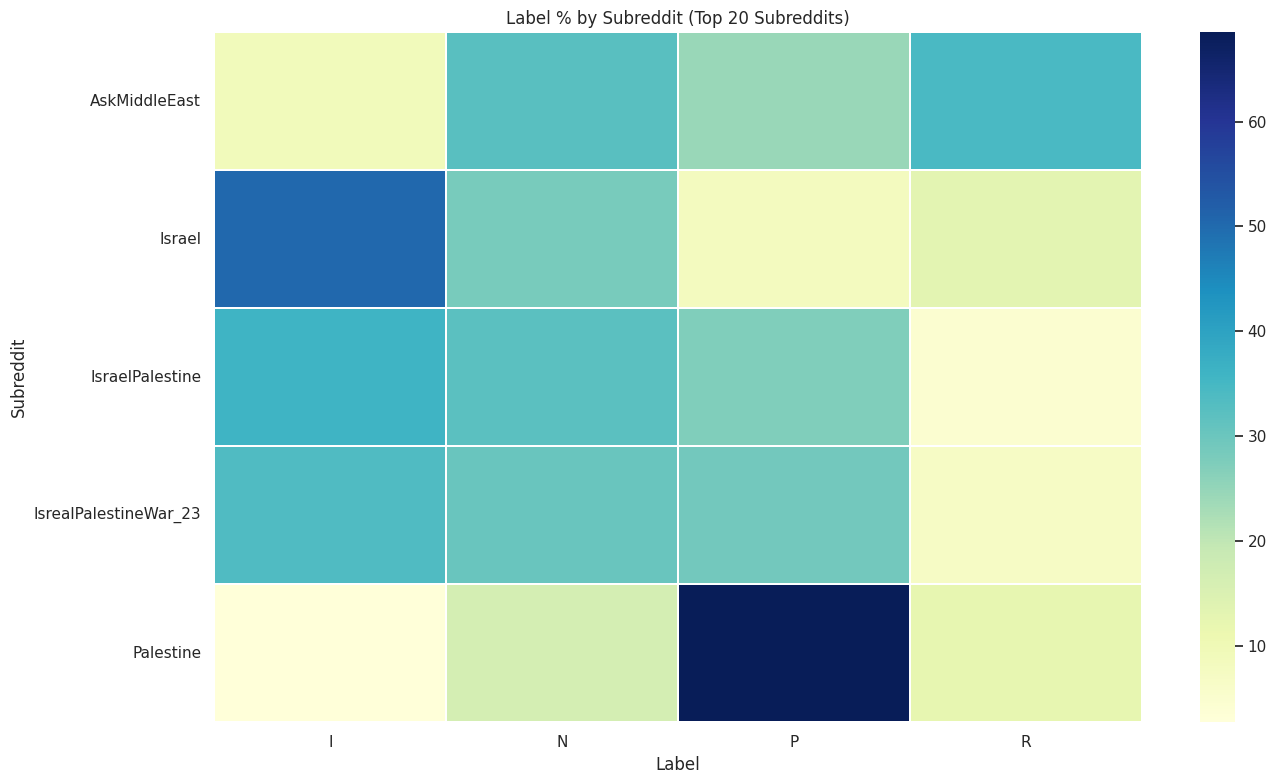

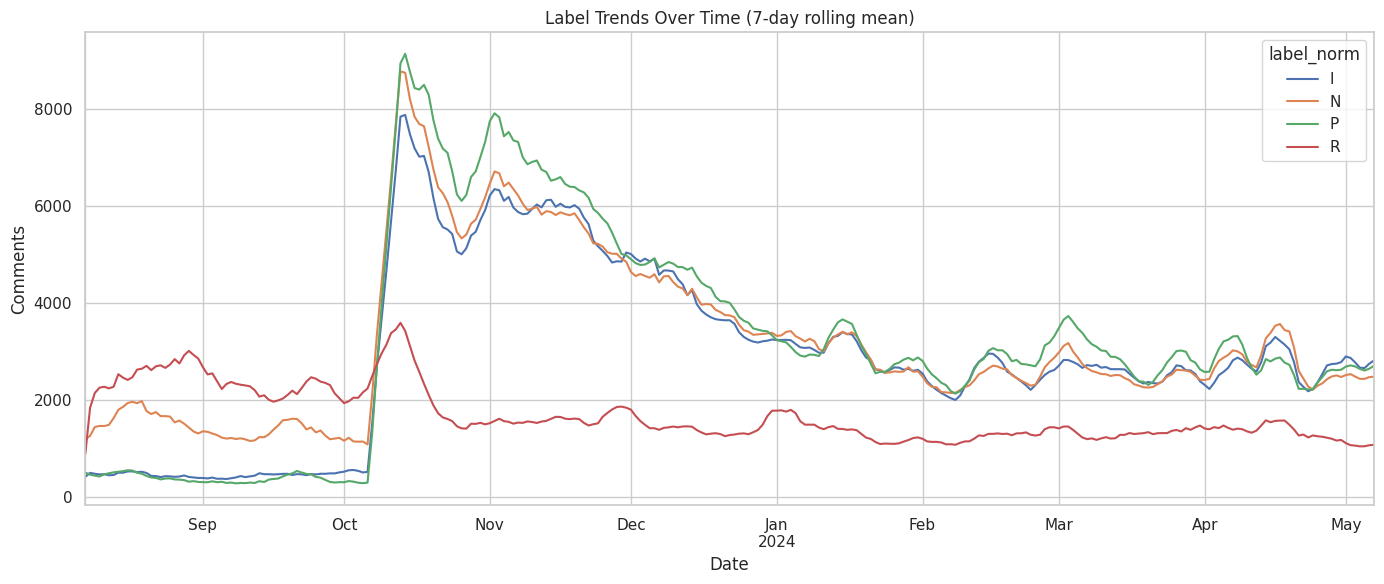

Risk labels used: ['I', 'N', 'P']
Top subreddits by risk % (min 20 comments):


,subreddit_norm,total_comments,risk_comments,avg_confidence,risk_pct
2,IsraelPalestine,1219500,1162461,NaN,95.32
3,IsrealPalestineWar_23,40819,37951,NaN,92.97
4,Palestine,452113,396228,NaN,87.64
1,Israel,564243,490306,NaN,86.90
0,AskMiddleEast,781040,512959,NaN,65.68


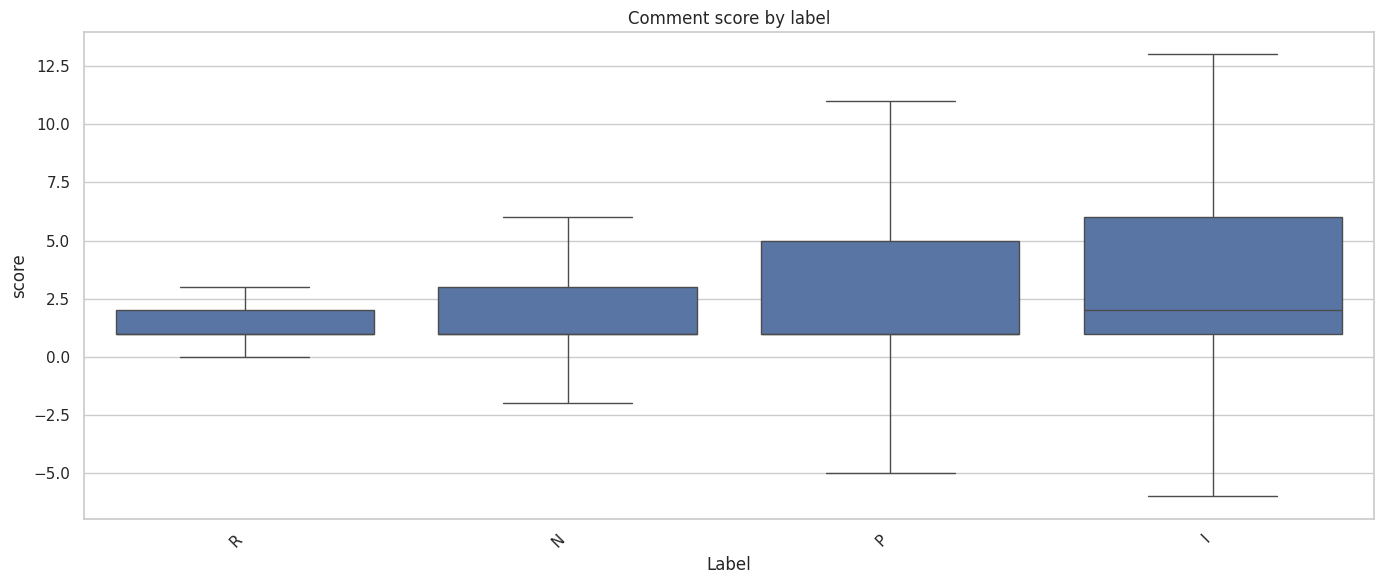

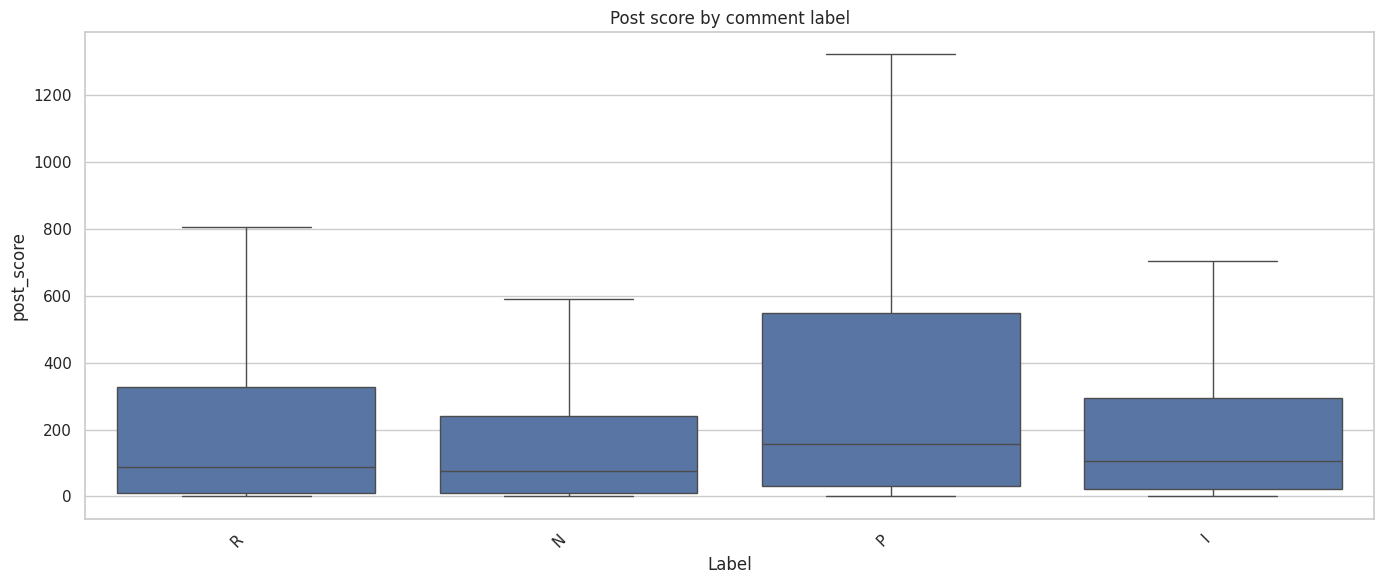

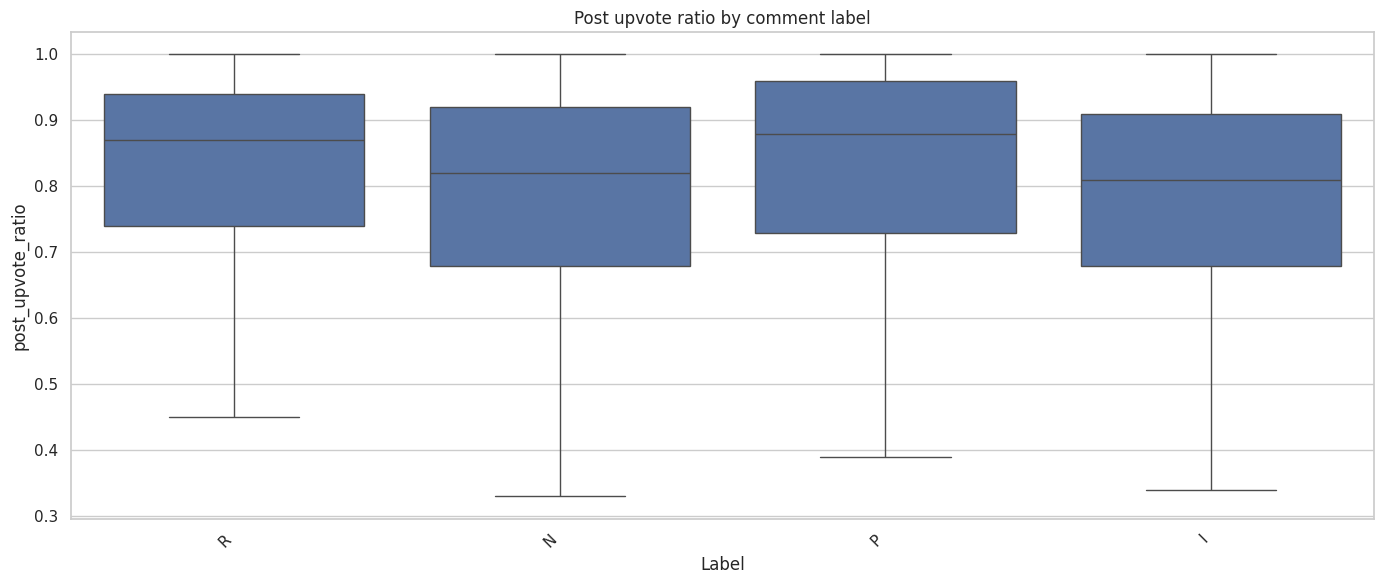

Controversiality rate by label (%):


,label_norm,is_controversial
2,P,5.23
1,N,3.32
3,R,3.10
0,I,2.86


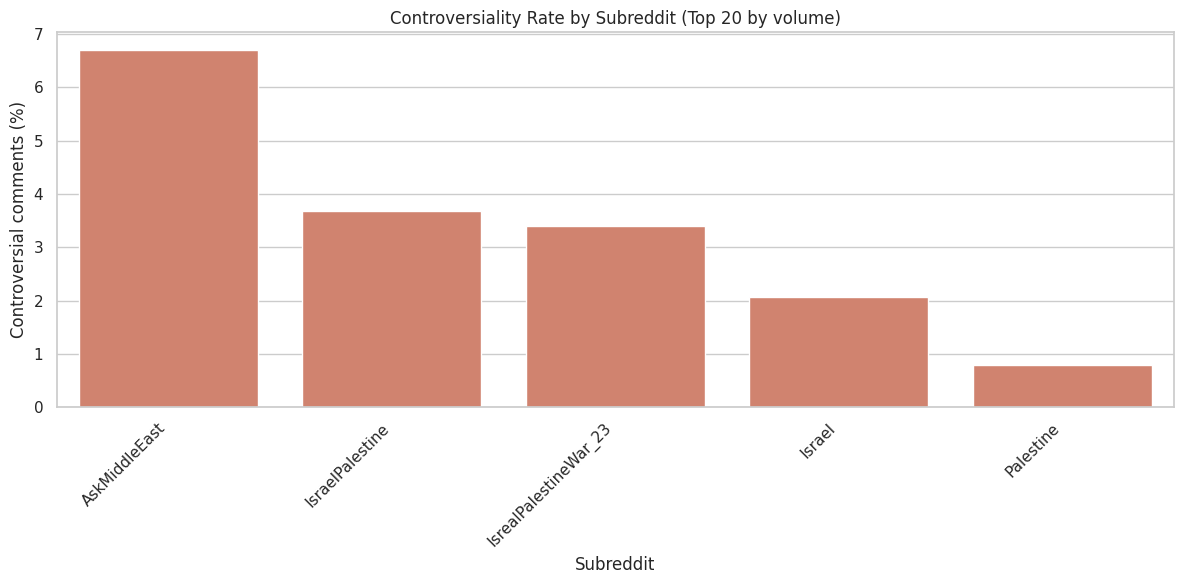

Post-level sample:


,post_id,comments_observed,unique_labels,post_num_comments,avg_post_score,avg_post_upvote_ratio
0,15k5s2e,22,4,14,0.0,0.04
1,15k6fws,2,1,1,6.0,1.00
2,15k74wd,1,1,1,8.0,1.00
3,15k7fd3,4,1,4,4.0,0.75
4,15k895f,9,1,8,2.0,0.75
5,15k8a5l,85,4,80,251.0,0.74
6,15k90yy,19,2,14,30.0,0.83
7,15k9vpi,802,4,739,2731.0,0.95
8,15k9yce,6,2,6,1.0,0.67
9,15kai3a,130,4,124,1.0,0.51


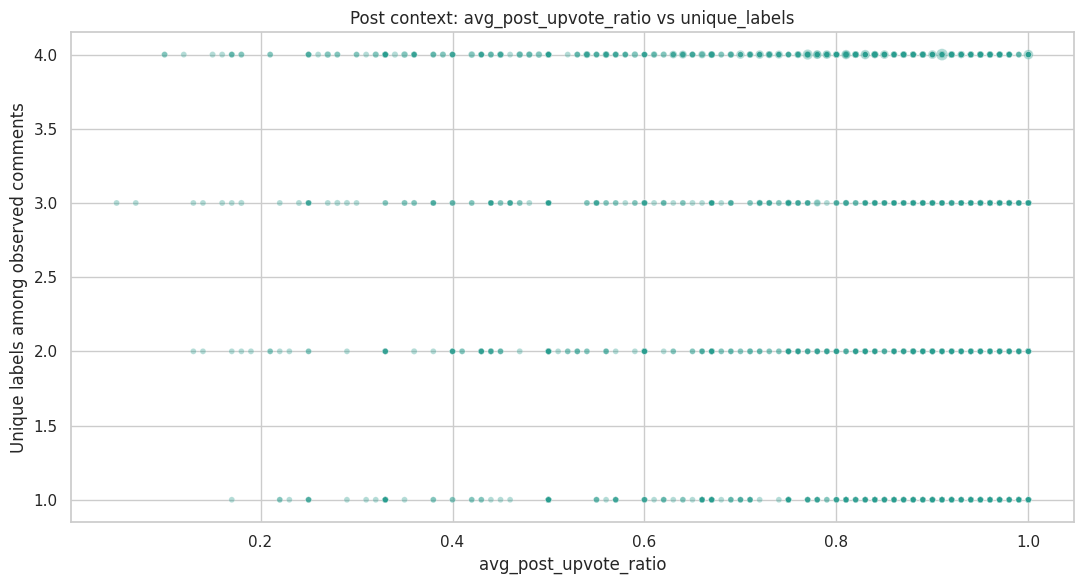

Top active authors (>=5 comments):


,author_name,comments,avg_score,controversial_rate,unique_subreddits
107461,[deleted],172163,1.308609,0.04,5
10090,AutoModerator,82228,1.013584,0.01,4
72699,Palestine-ModTeam,12195,1.315949,0.13,1
47501,Israel-ModTeam,10079,1.084334,0.04,1
49541,JosephL_55,9310,4.616649,0.70,2
143388,pinchasthegris,6732,2.951426,0.91,3
48734,JeffB1517,4276,3.292563,0.56,2
70536,OmryR,3708,7.262945,0.59,2
78180,Queasy_Ad_7297,3667,2.594219,0.55,2
147338,sad-frogpepe,3482,16.319070,0.72,3


Parent type x label (%):


label_norm,I,N,P,R
parent_type,,,,
reply_to_comment,28.12,32.03,26.78,13.08
reply_to_post,23.55,22.25,34.79,19.41


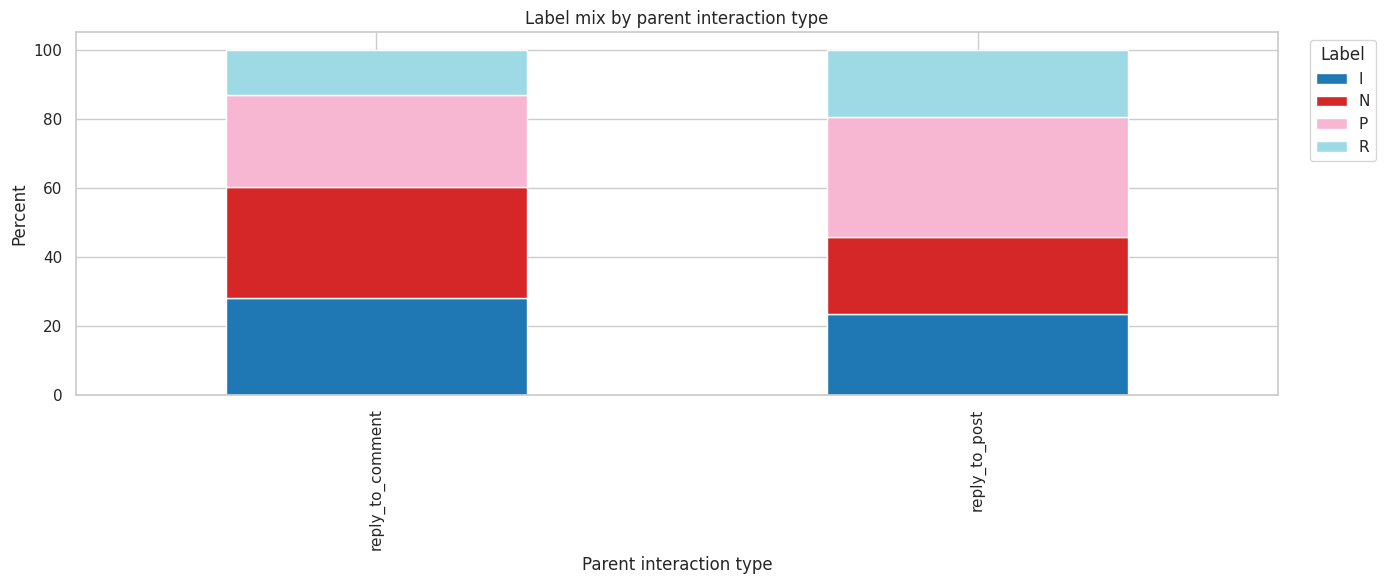

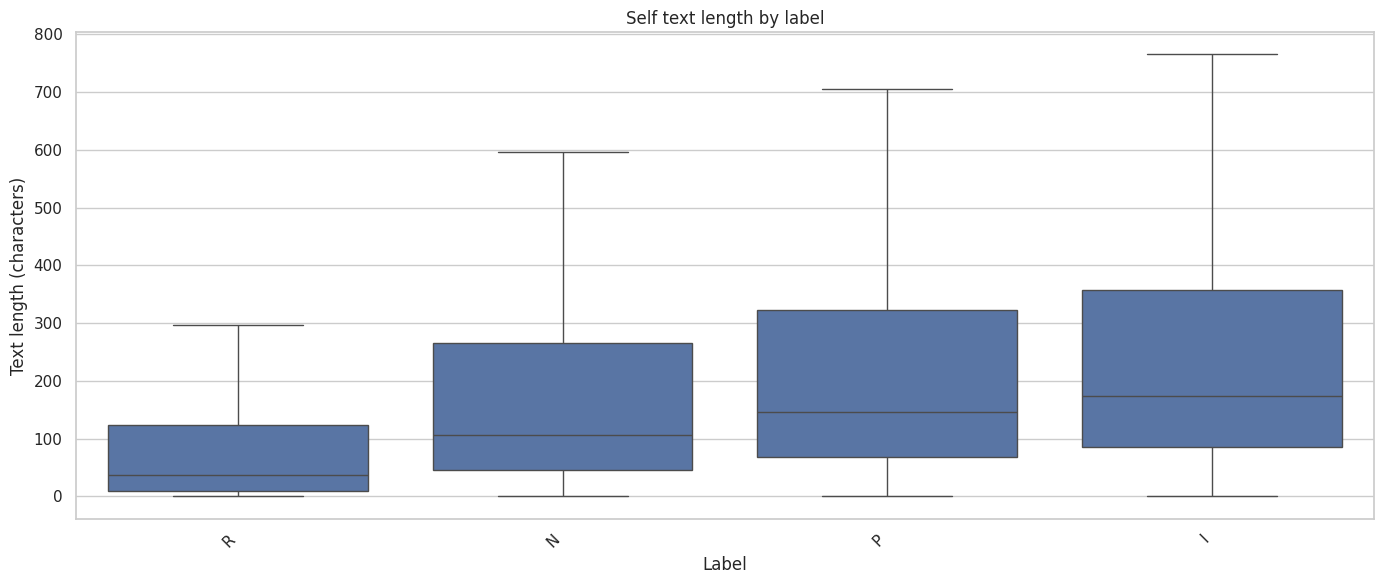

Average reasoning length by label:


,label_norm,reasoning_len
0,I,127.27
2,P,124.46
1,N,108.58
3,R,91.58


Top reasoning tokens by label (top 6 labels):
- P: [('the', 1610849), ('comment', 743244), ('and', 685838), ('for', 576627), ('palestine', 565497), ('israel', 501315), ('support', 438535), ('that', 414971), ('actions', 279953), ('palestinian', 263464), ('indicating', 259383), ('implies', 254262)]
- N: [('the', 1903742), ('comment', 787476), ('stance', 683002), ('conflict', 605867), ('and', 594880), ('clear', 506071), ('not', 466253), ('does', 399157), ('israel', 316950), ('without', 249919), ('discusses', 238743), ('gaza', 217309)]
- I: [('the', 1450697), ('israel', 957379), ('comment', 737917), ('and', 620077), ('that', 528070), ('for', 483622), ('support', 354861), ('implies', 267418), ('pro', 239475), ('stance', 237928), ('hamas', 217016), ('actions', 202276)]
- R: [('the', 899912), ('and', 452917), ('conflict', 366543), ('israel', 331522), ('comment', 320260), ('gaza', 295438), ('post', 275593), ('not', 229774), ('about', 164359), ('does', 137120), ('removed', 133112), ('are', 1043

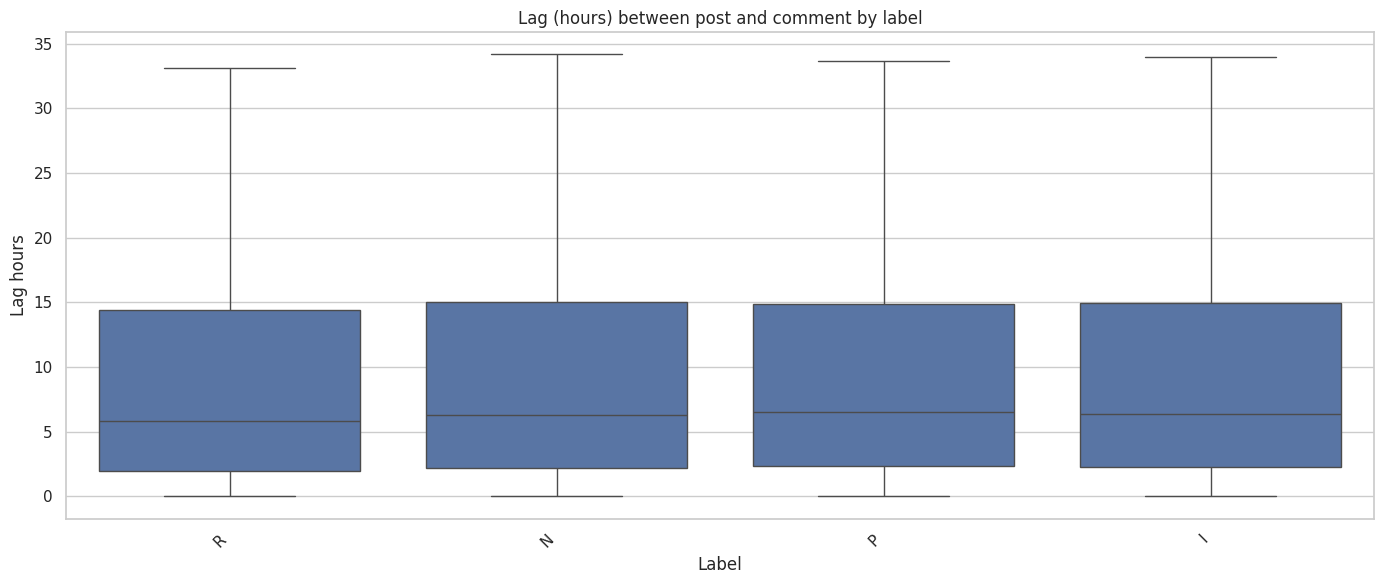

Time split counts:
time_split
train    2446172
test      611543
Name: count, dtype: int64
Subreddit split counts:
subreddit_split
train    2276675
test      781040
Name: count, dtype: int64
Review set size: 415,418


,comment_id,label_norm,confidence_num,subreddit_norm,score,is_controversial,created_dt,post_id,author_name,self_text
0,jv4bsx9,N,NaN,AskMiddleEast,149,0,2023-08-07 04:17:34+00:00,15k9vpi,frostythesohyonhater,1. We can't even vote them anyway so he is spe...
1,jv4byxc,N,NaN,AskMiddleEast,35,0,2023-08-07 04:19:15+00:00,15k9vpi,furiouslayer732,Nearly all migration in the world happens for ...
2,jv4cals,N,NaN,AskMiddleEast,32,0,2023-08-07 04:22:30+00:00,15k9vpi,Heliopolis1992,I definitely agree with your points! \n\nThe w...
3,jv4fo05,N,NaN,AskMiddleEast,17,1,2023-08-07 04:58:02+00:00,15k9vpi,Far_Arm_3793,Comparing Sharia to DAESH is mad. If you think...
4,jv4gje4,N,NaN,AskMiddleEast,16,0,2023-08-07 05:07:38+00:00,15k9vpi,Vohuman,"Largely true unfortunately, we ask for corrupt..."
5,jv4ir67,N,NaN,AskMiddleEast,18,0,2023-08-07 05:32:58+00:00,15k9vpi,BrotherTraining3771,"If you could earn $50,000 USD equivalent in mo..."
6,jv4j8vs,N,NaN,AskMiddleEast,239,0,2023-08-07 05:38:39+00:00,15k9vpi,riyadhb4,I'd rather live in a state where I'm paid well.
7,jv4kkwq,N,NaN,AskMiddleEast,23,0,2023-08-07 05:54:22+00:00,15k9vpi,TransportationSea514,Because of Western interventions spreading “de...
8,jv4kvr3,N,NaN,AskMiddleEast,34,0,2023-08-07 05:58:02+00:00,15k9vpi,Emotional-Floor-897,You literally did not read what he wrote did you?
9,jv4l694,N,NaN,AskMiddleEast,29,0,2023-08-07 06:01:35+00:00,15k9vpi,Emotional-Floor-897,???


Saved: review_set.csv


In [7]:
# ALL-IN-ONE EDA CELL (run this single cell)

import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"
chunk_size = 100_000
MAX_ROWS = None  # set e.g. 300_000 for faster dev runs

with open(file_path, "r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())


def pick_col(candidates):
    for c in candidates:
        if c in first_row:
            return c
    return None


label_col = pick_col(["Label", "label"])
confidence_col = pick_col(["Confidence", "confidence"])
reason_col = pick_col(["Reasoning", "reasoning"])
created_col = pick_col(["created_time", "created_at", "created"])
post_created_col = pick_col(["post_created_time", "post_created_at", "post_time"])

base_cols = [
    label_col,
    confidence_col,
    reason_col,
    created_col,
    post_created_col,
    "subreddit",
    "self_text",
    "comment_id",
    "score",
    "author_name",
    "controversiality",
    "post_id",
    "parent_id",
    "permalink",
    "post_title",
    "post_score",
    "post_upvote_ratio",
    "num_comments",
]
selected_cols = [c for c in dict.fromkeys(base_cols) if c and c in first_row]


def parse_mixed_datetime_series(series: pd.Series) -> pd.Series:
    raw = series.copy()
    out = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns, UTC]")

    num = pd.to_numeric(raw, errors="coerce")
    num_valid = num.dropna()

    if not num_valid.empty:
        med = float(num_valid.median())
        if med > 1e17:
            unit = "ns"
        elif med > 1e14:
            unit = "us"
        elif med > 1e11:
            unit = "ms"
        else:
            unit = "s"

        out.loc[num_valid.index] = pd.to_datetime(num_valid, unit=unit, utc=True, errors="coerce")

    non_num_idx = raw.index[num.isna()]
    if len(non_num_idx) > 0:
        out.loc[non_num_idx] = pd.to_datetime(raw.loc[non_num_idx], utc=True, errors="coerce")

    lower = pd.Timestamp("2005-01-01", tz="UTC")
    upper = pd.Timestamp.now(tz="UTC") + pd.Timedelta(days=1)
    out = out.where((out >= lower) & (out <= upper))

    return out


frames = []
rows_loaded = 0

for chunk in pd.read_json(file_path, lines=True, chunksize=chunk_size):
    cols = [c for c in selected_cols if c in chunk.columns]
    c = chunk[cols].copy()

    if label_col and label_col in c.columns:
        c["label_norm"] = c[label_col].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
    else:
        c["label_norm"] = "Unknown"

    if "subreddit" in c.columns:
        c["subreddit_norm"] = c["subreddit"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
    else:
        c["subreddit_norm"] = "Unknown"

    if confidence_col and confidence_col in c.columns:
        c["confidence_num"] = pd.to_numeric(c[confidence_col], errors="coerce")
    else:
        c["confidence_num"] = np.nan

    if created_col and created_col in c.columns:
        c["created_dt"] = parse_mixed_datetime_series(c[created_col])
    else:
        c["created_dt"] = pd.NaT

    if post_created_col and post_created_col in c.columns:
        c["post_created_dt"] = parse_mixed_datetime_series(c[post_created_col])
    else:
        c["post_created_dt"] = pd.NaT

    for ncol in ["score", "post_score", "post_upvote_ratio", "num_comments", "controversiality"]:
        if ncol in c.columns:
            c[ncol] = pd.to_numeric(c[ncol], errors="coerce")

    if "self_text" in c.columns:
        c["self_text_len"] = c["self_text"].fillna("").astype(str).str.len()
    else:
        c["self_text_len"] = 0

    if reason_col and reason_col in c.columns:
        c["reasoning_len"] = c[reason_col].fillna("").astype(str).str.len()
    else:
        c["reasoning_len"] = 0

    if "parent_id" in c.columns:
        p = c["parent_id"].fillna("").astype(str)
        c["parent_type"] = np.select(
            [p.str.startswith("t1_"), p.str.startswith("t3_")],
            ["reply_to_comment", "reply_to_post"],
            default="other_or_missing",
        )
    else:
        c["parent_type"] = "missing"

    frames.append(c)
    rows_loaded += len(c)

    if MAX_ROWS is not None and rows_loaded >= MAX_ROWS:
        break

if not frames:
    raise ValueError("No data was loaded from JSONL file.")

df = pd.concat(frames, ignore_index=True)
if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.iloc[:MAX_ROWS].copy()

if "comment_id" not in df.columns:
    df["comment_id"] = df.index.astype(str)

df["is_controversial"] = (pd.to_numeric(df.get("controversiality", 0), errors="coerce").fillna(0) > 0).astype(int)

print(f"Rows loaded: {len(df):,}")
print(f"Columns available: {list(df.columns)}")
display(df.head(3))

# 1) Data quality checks
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missing columns (%):")
display(missing_pct.head(20).round(2).to_frame("missing_pct"))

for key_col in ["comment_id", "permalink"]:
    if key_col in df.columns:
        dup_count = int(df[key_col].duplicated().sum())
        print(f"Duplicate {key_col}: {dup_count:,}")

if "created_dt" in df.columns:
    print(f"Valid created_dt rows: {df['created_dt'].notna().sum():,}")
    if df["created_dt"].notna().any():
        print("created_dt range:", df["created_dt"].min(), "to", df["created_dt"].max())

if "post_created_dt" in df.columns:
    print(f"Valid post_created_dt rows: {df['post_created_dt'].notna().sum():,}")

# 2) Label x subreddit, confidence, trends, risk ranking
sub_top = df["subreddit_norm"].value_counts().head(20).index
tmp = df[df["subreddit_norm"].isin(sub_top)].copy()
heat = pd.crosstab(tmp["subreddit_norm"], tmp["label_norm"], normalize="index") * 100

plt.figure(figsize=(14, 8))
sns.heatmap(heat, cmap="YlGnBu", linewidths=0.3)
plt.title("Label % by Subreddit (Top 20 Subreddits)")
plt.xlabel("Label")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

conf_df = df.dropna(subset=["confidence_num"]).copy()
if not conf_df.empty:
    top_labels = df["label_norm"].value_counts().head(12).index
    conf_plot = conf_df[conf_df["label_norm"].isin(top_labels)]

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=conf_plot, x="label_norm", y="confidence_num", showfliers=False)
    plt.title("Confidence by Label (Top 12 labels)")
    plt.xlabel("Label")
    plt.ylabel("Confidence")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

trend_df = df.dropna(subset=["created_dt"]).copy()
if not trend_df.empty:
    trend_df["date"] = trend_df["created_dt"].dt.floor("D")
    daily = trend_df.groupby(["date", "label_norm"]).size().reset_index(name="count")
    top_labels_trend = trend_df["label_norm"].value_counts().head(8).index
    daily_top = daily[daily["label_norm"].isin(top_labels_trend)]

    pivot = daily_top.pivot(index="date", columns="label_norm", values="count").fillna(0)
    smooth = pivot.rolling(7, min_periods=1).mean()

    plt.figure(figsize=(14, 6))
    smooth.plot(ax=plt.gca())
    plt.title("Label Trends Over Time (7-day rolling mean)")
    plt.xlabel("Date")
    plt.ylabel("Comments")
    plt.tight_layout()
    plt.show()

risk_keywords = ["toxic", "hate", "abuse", "harass", "offensive", "violent", "threat", "racis", "sexis", "misog", "spam", "nsfw"]
all_labels = sorted(df["label_norm"].dropna().unique())
risk_labels = [l for l in all_labels if any(k in l.lower() for k in risk_keywords)]
if not risk_labels:
    risk_labels = [l for l in all_labels if l.lower() not in {"neutral", "unknown", "none"}]
    risk_labels = risk_labels[: max(1, min(3, len(risk_labels)))]

print("Risk labels used:", risk_labels)

risk_stats = (
    df.groupby("subreddit_norm")
    .agg(
        total_comments=("label_norm", "size"),
        risk_comments=("label_norm", lambda s: s.isin(risk_labels).sum()),
        avg_confidence=("confidence_num", "mean"),
    )
    .reset_index()
)
risk_stats["risk_pct"] = (risk_stats["risk_comments"] / risk_stats["total_comments"] * 100).round(2)
risk_rank = risk_stats[risk_stats["total_comments"] >= 20].sort_values(["risk_pct", "total_comments"], ascending=[False, False]).head(25)
print("Top subreddits by risk % (min 20 comments):")
display(risk_rank)

# 3) Engagement, controversiality, post-level context
metrics = [
    ("score", "Comment score by label"),
    ("post_score", "Post score by comment label"),
    ("post_upvote_ratio", "Post upvote ratio by comment label"),
]

top_labels_eng = df["label_norm"].value_counts().head(12).index
for col, title in metrics:
    if col in df.columns:
        plot_df = df[df["label_norm"].isin(top_labels_eng)].copy()
        plt.figure(figsize=(14, 6))
        sns.boxplot(data=plot_df, x="label_norm", y=col, showfliers=False)
        plt.title(title)
        plt.xlabel("Label")
        plt.ylabel(col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

cont_label = df.groupby("label_norm", as_index=False)["is_controversial"].mean().sort_values("is_controversial", ascending=False)
cont_label["is_controversial"] = (cont_label["is_controversial"] * 100).round(2)
print("Controversiality rate by label (%):")
display(cont_label.head(20))

sub_top20 = df["subreddit_norm"].value_counts().head(20).index
cont_sub = (
    df[df["subreddit_norm"].isin(sub_top20)]
    .groupby("subreddit_norm", as_index=False)["is_controversial"]
    .mean()
    .sort_values("is_controversial", ascending=False)
)
cont_sub["is_controversial"] = (cont_sub["is_controversial"] * 100).round(2)

plt.figure(figsize=(12, 6))
sns.barplot(data=cont_sub, x="subreddit_norm", y="is_controversial", color="#E07A5F")
plt.title("Controversiality Rate by Subreddit (Top 20 by volume)")
plt.xlabel("Subreddit")
plt.ylabel("Controversial comments (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "post_id" in df.columns:
    post_aggs = {
        "comments_observed": ("label_norm", "size"),
        "unique_labels": ("label_norm", "nunique"),
    }
    if "num_comments" in df.columns:
        post_aggs["post_num_comments"] = ("num_comments", "max")
    if "post_score" in df.columns:
        post_aggs["avg_post_score"] = ("post_score", "mean")
    if "post_upvote_ratio" in df.columns:
        post_aggs["avg_post_upvote_ratio"] = ("post_upvote_ratio", "mean")

    post_level = df.groupby("post_id").agg(**post_aggs).reset_index()
    print("Post-level sample:")
    display(post_level.head(10))

    x_col = "avg_post_upvote_ratio" if "avg_post_upvote_ratio" in post_level.columns else ("avg_post_score" if "avg_post_score" in post_level.columns else None)
    if x_col is not None:
        sample_n = min(3000, len(post_level))
        sample_post = post_level.sample(sample_n, random_state=42) if sample_n > 0 else post_level

        plt.figure(figsize=(11, 6))
        sns.scatterplot(data=sample_post, x=x_col, y="unique_labels", size="comments_observed", alpha=0.35, legend=False, color="#2A9D8F")
        plt.title(f"Post context: {x_col} vs unique_labels")
        plt.xlabel(x_col)
        plt.ylabel("Unique labels among observed comments")
        plt.tight_layout()
        plt.show()

# 4) Author, parent interaction, text/reasoning, lag, splits, review set
if "author_name" in df.columns:
    author_df = df.copy()
    author_df["author_name"] = author_df["author_name"].fillna("Unknown").astype(str)

    author_stats = (
        author_df.groupby("author_name")
        .agg(
            comments=("label_norm", "size"),
            avg_score=("score", "mean") if "score" in author_df.columns else ("label_norm", "size"),
            controversial_rate=("is_controversial", "mean"),
            unique_subreddits=("subreddit_norm", "nunique"),
        )
        .reset_index()
    )
    if "score" not in author_df.columns:
        author_stats["avg_score"] = np.nan

    author_stats["controversial_rate"] = (author_stats["controversial_rate"] * 100).round(2)
    author_active = author_stats[author_stats["comments"] >= 5].sort_values("comments", ascending=False)
    print("Top active authors (>=5 comments):")
    display(author_active.head(25))

parent_mix = pd.crosstab(df["parent_type"], df["label_norm"], normalize="index") * 100
print("Parent type x label (%):")
display(parent_mix.round(2))

plt.figure(figsize=(14, 6))
parent_mix.plot(kind="bar", stacked=True, colormap="tab20", ax=plt.gca())
plt.title("Label mix by parent interaction type")
plt.xlabel("Parent interaction type")
plt.ylabel("Percent")
plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

top_labels_len = df["label_norm"].value_counts().head(10).index
len_df = df[df["label_norm"].isin(top_labels_len)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=len_df, x="label_norm", y="self_text_len", showfliers=False)
plt.title("Self text length by label")
plt.xlabel("Label")
plt.ylabel("Text length (characters)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "reasoning_len" in df.columns and df["reasoning_len"].gt(0).any():
    reason_len = df.groupby("label_norm", as_index=False)["reasoning_len"].mean().sort_values("reasoning_len", ascending=False)
    print("Average reasoning length by label:")
    display(reason_len.head(20).round(2))

    tmp2 = df.dropna(subset=["confidence_num"]).copy()
    tmp2 = tmp2[tmp2["reasoning_len"] > 0]
    if not tmp2.empty:
        tmp2["confidence_bin"] = pd.qcut(tmp2["confidence_num"], q=5, duplicates="drop")
        conf_reason = tmp2.groupby("confidence_bin", as_index=False)["reasoning_len"].mean()
        print("Reasoning length by confidence bin:")
        display(conf_reason.round(2))

    def top_tokens(texts, n=12):
        counter = Counter()
        for t in texts.dropna().astype(str):
            toks = re.findall(r"[a-zA-Z]{3,}", t.lower())
            counter.update(toks)
        return counter.most_common(n)

    reason_col_name = reason_col if reason_col in df.columns else None
    if reason_col_name:
        print("Top reasoning tokens by label (top 6 labels):")
        for lbl in df["label_norm"].value_counts().head(6).index:
            pairs = top_tokens(df.loc[df["label_norm"] == lbl, reason_col_name])
            print(f"- {lbl}: {pairs}")

if "created_dt" in df.columns and "post_created_dt" in df.columns:
    df["lag_hours"] = (df["created_dt"] - df["post_created_dt"]).dt.total_seconds() / 3600
    lag_df = df[df["lag_hours"].notna()].copy()
    lag_df = lag_df[(lag_df["lag_hours"] >= 0) & (lag_df["lag_hours"] <= 24 * 365 * 10)]

    if not lag_df.empty:
        top_labels_lag = lag_df["label_norm"].value_counts().head(10).index
        lag_plot = lag_df[lag_df["label_norm"].isin(top_labels_lag)]

        plt.figure(figsize=(14, 6))
        sns.boxplot(data=lag_plot, x="label_norm", y="lag_hours", showfliers=False)
        plt.title("Lag (hours) between post and comment by label")
        plt.xlabel("Label")
        plt.ylabel("Lag hours")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if "created_dt" in df.columns and df["created_dt"].notna().any():
    cutoff = df["created_dt"].dropna().quantile(0.8)
    df["time_split"] = np.where(df["created_dt"] <= cutoff, "train", "test")
    print("Time split counts:")
    print(df["time_split"].value_counts(dropna=False))

subs_unique = np.array(sorted(df["subreddit_norm"].dropna().unique()))
if len(subs_unique) > 0:
    rng = np.random.default_rng(42)
    test_size = max(1, int(len(subs_unique) * 0.2))
    test_subs = set(rng.choice(subs_unique, size=test_size, replace=False))
    df["subreddit_split"] = np.where(df["subreddit_norm"].isin(test_subs), "test", "train")
    print("Subreddit split counts:")
    print(df["subreddit_split"].value_counts(dropna=False))

review_parts = []
if df["confidence_num"].notna().any():
    low_conf_cut = df["confidence_num"].quantile(0.10)
    review_parts.append(df[df["confidence_num"] <= low_conf_cut])

if "score" in df.columns and df["score"].notna().any() and len(risk_labels) > 0:
    high_score_cut = df["score"].quantile(0.90)
    review_parts.append(df[(df["score"] >= high_score_cut) & (df["label_norm"].isin(risk_labels))])

if df["confidence_num"].notna().any():
    uncertain_cut = df["confidence_num"].quantile(0.25)
    review_parts.append(df[(df["is_controversial"] == 1) & (df["confidence_num"] <= uncertain_cut)])
else:
    review_parts.append(df[df["is_controversial"] == 1])

review_set = pd.concat(review_parts, ignore_index=True) if review_parts else pd.DataFrame(columns=df.columns)
dedupe_cols = [c for c in ["comment_id", "permalink"] if c in review_set.columns]
if dedupe_cols:
    review_set = review_set.drop_duplicates(subset=dedupe_cols)
else:
    review_set = review_set.drop_duplicates()

review_cols = [
    c
    for c in [
        "comment_id", "label_norm", "confidence_num", "subreddit_norm", "score",
        "is_controversial", "created_dt", "post_id", "author_name", "self_text"
    ]
    if c in review_set.columns
]
print(f"Review set size: {len(review_set):,}")
display(review_set[review_cols].head(50))

review_set.to_csv("/kaggle/working/review_set.csv", index=False)
print("Saved: review_set.csv")

In [8]:
import json
from itertools import islice

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"

with open(file_path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in islice(f, 3)]

for i, row in enumerate(rows, 1):
    print(f"\n--- Row {i} ---")
    print(json.dumps(row, indent=2, ensure_ascii=False, default=str))


--- Row 1 ---
{
  "index": 0,
  "Label": "R",
  "Confidence": "High",
  "Reasoning": "The post is about the new Twitter logo and has no relation to the Israel-Gaza conflict.",
  "__row_index": 0,
  "self_text": "It's just to show their background and in this sub its to show super nationalistic joke backgrounds. At least that's what I understand haha",
  "comment_id": "jv42f8z",
  "score": "3",
  "author_name": "Heliopolis1992",
  "controversiality": "0",
  "created_time": "1691376701",
  "subreddit": "AskMiddleEast",
  "post_id": "15k895f",
  "parent_id": "t3_15k895f",
  "permalink": "/r/AskMiddleEast/comments/15k895f/can_anyone_explain_the_obsession_with_the/jv42f8z/",
  "post_title": "Can anyone explain the obsession with the multiple posts on the new Twitter logo?",
  "post_score": "2",
  "post_upvote_ratio": "0.75",
  "post_created_time": "1691376352",
  "num_comments": "8"
}

--- Row 2 ---
{
  "index": 1,
  "Label": "R",
  "Confidence": "High",
  "Reasoning": "The post is about t

In [9]:
import json

file_path = "/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl"

first_by_label = {}

with open(file_path, "r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())
    label_col = "Label" if "Label" in first_row else "label"

    # include first row
    label = str(first_row.get(label_col, "Unknown")).strip() or "Unknown"
    first_by_label[label] = first_row

    # stream remaining rows
    for line in f:
        row = json.loads(line)
        label = str(row.get(label_col, "Unknown")).strip() or "Unknown"
        if label not in first_by_label:
            first_by_label[label] = row

samples = list(first_by_label.values())

print(f"Found {len(samples)} labels")
print("Labels:", sorted(first_by_label.keys()))

# full object output (not truncated)
print(json.dumps(samples, indent=2, ensure_ascii=False, default=str))

# optional: save
# with open("one_per_label.json", "w", encoding="utf-8") as out:
#     json.dump(samples, out, ensure_ascii=False, indent=2, default=str)

# print("Saved: one_per_label.json")

Found 4 labels
Labels: ['I', 'N', 'P', 'R']
[
  {
    "index": 0,
    "Label": "R",
    "Confidence": "High",
    "Reasoning": "The post is about the new Twitter logo and has no relation to the Israel-Gaza conflict.",
    "__row_index": 0,
    "self_text": "It's just to show their background and in this sub its to show super nationalistic joke backgrounds. At least that's what I understand haha",
    "comment_id": "jv42f8z",
    "score": "3",
    "author_name": "Heliopolis1992",
    "controversiality": "0",
    "created_time": "1691376701",
    "subreddit": "AskMiddleEast",
    "post_id": "15k895f",
    "parent_id": "t3_15k895f",
    "permalink": "/r/AskMiddleEast/comments/15k895f/can_anyone_explain_the_obsession_with_the/jv42f8z/",
    "post_title": "Can anyone explain the obsession with the multiple posts on the new Twitter logo?",
    "post_score": "2",
    "post_upvote_ratio": "0.75",
    "post_created_time": "1691376352",
    "num_comments": "8"
  },
  {
    "index": 6,
    "Label

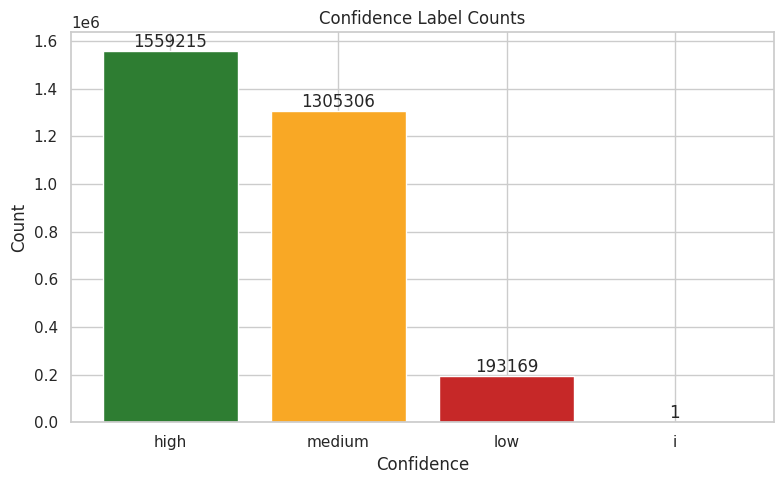

Counts: {'high': 1559215, 'medium': 1305306, 'low': 193169, 'i': 1}


In [10]:
# Kaggle-friendly: memory-optimized JSONL streaming + bar chart for text confidence labels

import json
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

# Update this path if needed in Kaggle
# Example: "/kaggle/input/your-dataset/reddit_labeled_full.jsonl"
file_path = Path("/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl")

counts = Counter()
confidence_key = None

with file_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            continue  # skip bad lines safely

        # Detect once (supports both Confidence / confidence)
        if confidence_key is None:
            if "Confidence" in row:
                confidence_key = "Confidence"
            elif "confidence" in row:
                confidence_key = "confidence"
            else:
                continue

        conf = str(row.get(confidence_key, "")).strip().lower()
        if conf:
            counts[conf] += 1

if not counts:
    raise ValueError("No confidence values found in file.")

# Keep expected order first, then any extra labels
preferred_order = ["high", "medium", "low"]
labels = [x for x in preferred_order if x in counts] + sorted(
    [k for k in counts if k not in preferred_order]
)
values = [counts[k] for k in labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=["#2E7D32", "#F9A825", "#C62828"] + ["#607D8B"] * max(0, len(labels) - 3))
plt.title("Confidence Label Counts")
plt.xlabel("Confidence")
plt.ylabel("Count")

for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("Counts:", dict(counts))

Counts per label x confidence:


,low,medium,high,i,unknown,total
P,22344,374898,494609,0,6,891857
N,148721,496362,244931,1,6,890021
I,17932,429462,370624,0,9,818027
R,4172,4584,449051,0,3,457810


Percent distribution within each label:


,low,medium,high,i,unknown
P,2.51,42.04,55.46,0.0,0.0
N,16.71,55.77,27.52,0.0,0.0
I,2.19,52.50,45.31,0.0,0.0
R,0.91,1.00,98.09,0.0,0.0


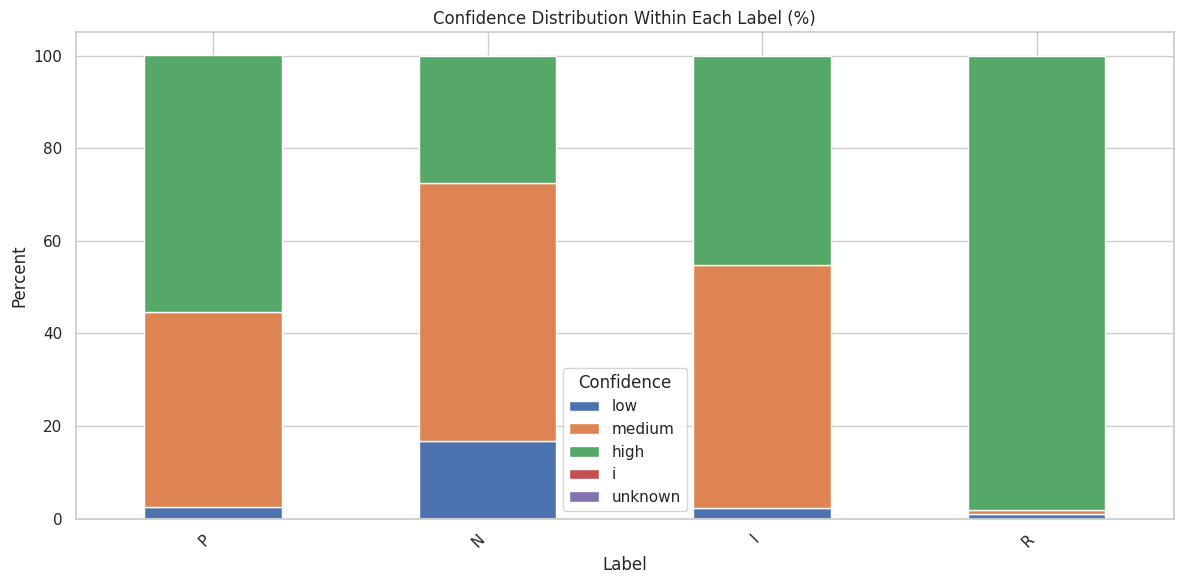

In [11]:
import json
from collections import defaultdict, Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Update path if needed, e.g. Path("/kaggle/input/your-dataset/reddit_labeled_full.jsonl")
file_path = Path("/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl")

label_conf_counts = defaultdict(Counter)
label_totals = Counter()

label_key = None
conf_key = None

with file_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            continue

        # Detect keys once
        if label_key is None:
            if "Label" in row:
                label_key = "Label"
            elif "label" in row:
                label_key = "label"

        if conf_key is None:
            if "Confidence" in row:
                conf_key = "Confidence"
            elif "confidence" in row:
                conf_key = "confidence"

        if label_key is None or conf_key is None:
            continue

        label = str(row.get(label_key, "")).strip()
        conf = str(row.get(conf_key, "")).strip().lower()

        if label == "":
            label = "Unknown"
        if conf == "":
            conf = "unknown"

        label_conf_counts[label][conf] += 1
        label_totals[label] += 1

if not label_conf_counts:
    raise ValueError("No label-confidence data found.")

# Build count table
count_df = pd.DataFrame.from_dict(label_conf_counts, orient="index").fillna(0).astype(int)

# Put expected confidence labels first
preferred_cols = [c for c in ["low", "medium", "high"] if c in count_df.columns]
other_cols = sorted([c for c in count_df.columns if c not in preferred_cols])
count_df = count_df[preferred_cols + other_cols]

count_df["total"] = count_df.sum(axis=1)
count_df = count_df.sort_values("total", ascending=False)

# Percentage table within each label
pct_df = (
    count_df.drop(columns="total")
    .div(count_df["total"], axis=0)
    .mul(100)
    .round(2)
)

print("Counts per label x confidence:")
display(count_df)

print("Percent distribution within each label:")
display(pct_df)

# Optional plot: percentage distribution (stacked bar)
plot_df = pct_df.copy()
plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Confidence Distribution Within Each Label (%)")
plt.xlabel("Label")
plt.ylabel("Percent")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Confidence")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# FILTER DATASET:
# 1) Remove rows where label == "R"
# 2) Keep ONLY high-confidence rows
# 3) Export filtered JSONL + CSV
# Kaggle memory-safe streaming version
# ============================================

import json
from pathlib import Path
from collections import Counter

# INPUT FILE
input_file = Path("/kaggle/input/datasets/akshat3144/reddit-labeled-full/reddit_labeled_full.jsonl")

# OUTPUT FILES
output_jsonl = Path("/kaggle/working/reddit_filtered_high_confidence.jsonl")
output_csv = Path("/kaggle/working/reddit_filtered_high_confidence.csv")

# -----------------------------
# Detect keys automatically
# -----------------------------
with input_file.open("r", encoding="utf-8") as f:
    first_row = json.loads(f.readline())

label_key = "Label" if "Label" in first_row else "label"
conf_key = "Confidence" if "Confidence" in first_row else "confidence"

print("Using label column:", label_key)
print("Using confidence column:", conf_key)

# -----------------------------
# Define HIGH confidence values
# (edit if needed after seeing your labels)
# -----------------------------
HIGH_CONF_VALUES = {
    "high",
    "very high",
    "high confidence",
    "very_high",
    "strong"
}

# -----------------------------
# Stream + filter
# -----------------------------
kept = 0
removed_r = 0
removed_low_conf = 0
bad_json = 0

rows_for_csv = []

with (
    input_file.open("r", encoding="utf-8") as fin,
    output_jsonl.open("w", encoding="utf-8") as fout
):

    for line in fin:
        line = line.strip()

        if not line:
            continue

        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            bad_json += 1
            continue

        # -----------------------------
        # LABEL FILTER
        # -----------------------------
        label = str(row.get(label_key, "")).strip()

        if label.upper() == "R":
            removed_r += 1
            continue

        # -----------------------------
        # CONFIDENCE FILTER
        # -----------------------------
        conf = str(row.get(conf_key, "")).strip().lower()

        if conf not in HIGH_CONF_VALUES:
            removed_low_conf += 1
            continue

        # -----------------------------
        # KEEP ROW
        # -----------------------------
        fout.write(json.dumps(row, ensure_ascii=False) + "\n")

        rows_for_csv.append(row)
        kept += 1

print("\n========== DONE ==========")
print("Rows kept:", kept)
print("Removed R label rows:", removed_r)
print("Removed low confidence rows:", removed_low_conf)
print("Bad JSON rows:", bad_json)

# -----------------------------
# SAVE CSV VERSION ALSO
# -----------------------------
import pandas as pd

df = pd.DataFrame(rows_for_csv)
df.to_csv(output_csv, index=False)

print("\nSaved JSONL:", output_jsonl)
print("Saved CSV:", output_csv)

# -----------------------------
# Quick verification
# -----------------------------
print("\nRemaining labels:")
print(df[label_key].value_counts())

print("\nRemaining confidence values:")
print(df[conf_key].value_counts())

In [ ]:
# ============================================
# REMOVE CONFIDENCE COLUMN
# since all remaining rows are High confidence
# ============================================

import json
from pathlib import Path

input_file = Path("/kaggle/working/reddit_filtered_high_confidence.jsonl")
output_file = Path("/kaggle/working/reddit_filtered_final.jsonl")

removed_column = 0
total_rows = 0

with (
    input_file.open("r", encoding="utf-8") as fin,
    output_file.open("w", encoding="utf-8") as fout
):

    for line in fin:
        row = json.loads(line)

        # remove confidence column safely
        if "Confidence" in row:
            row.pop("Confidence")
            removed_column += 1

        if "confidence" in row:
            row.pop("confidence")
            removed_column += 1

        fout.write(json.dumps(row, ensure_ascii=False) + "\n")
        total_rows += 1

print("Done.")
print("Rows processed:", total_rows)
print("Confidence columns removed:", removed_column)

print("\nFinal dataset saved at:")
print(output_file)

In [ ]:
# ============================================
# STRONG CSV vs JSONL VERIFICATION
# Handles parsing/type issues safely
# ============================================

import pandas as pd
import json
from pathlib import Path

csv_file = Path("/kaggle/working/reddit_filtered_high_confidence.csv")
jsonl_file = Path("/kaggle/working/reddit_filtered_high_confidence.jsonl")

# -----------------------------
# LOAD CSV AS STRINGS
# prevents dtype auto-conversion issues
# -----------------------------
df_csv = pd.read_csv(csv_file, dtype=str)

# -----------------------------
# LOAD JSONL
# -----------------------------
json_rows = []

bad_json = 0

with jsonl_file.open("r", encoding="utf-8") as f:
    for line_num, line in enumerate(f, start=1):

        try:
            row = json.loads(line)

            # convert all values to string
            row = {k: str(v) if v is not None else "" for k, v in row.items()}

            json_rows.append(row)

        except json.JSONDecodeError:
            bad_json += 1
            print(f"Bad JSON at line {line_num}")

df_json = pd.DataFrame(json_rows)

# -----------------------------
# NORMALIZE
# -----------------------------
df_csv = df_csv.fillna("").astype(str)
df_json = df_json.fillna("").astype(str)

# sort columns
df_csv = df_csv.reindex(sorted(df_csv.columns), axis=1)
df_json = df_json.reindex(sorted(df_json.columns), axis=1)

# -----------------------------
# BASIC CHECKS
# -----------------------------
print("CSV Shape :", df_csv.shape)
print("JSON Shape:", df_json.shape)

print("\nColumns identical?:")
print(list(df_csv.columns) == list(df_json.columns))

print("\nBad JSON rows:", bad_json)

# -----------------------------
# FULL DATA CHECK
# -----------------------------
same = df_csv.equals(df_json)

print("\nFully identical?:", same)

# -----------------------------
# FIND DIFFERENCES
# -----------------------------
if not same:

    diff_mask = (df_csv != df_json)

    diff_rows = diff_mask.any(axis=1)

    print("\nDifferent row count:", diff_rows.sum())

    differing_indices = diff_rows[diff_rows].index.tolist()[:5]

    for idx in differing_indices:

        print(f"\n========== ROW {idx} ==========")

        print("\nCSV:")
        print(df_csv.iloc[idx].to_dict())

        print("\nJSON:")
        print(df_json.iloc[idx].to_dict())

else:
    print("\nSUCCESS: CSV and JSONL are perfectly identical.")

In [ ]:
# print first 5 rows
df_csv.head()

In [ ]:
# print first 5 rows
df_json.head()

In [ ]:
# ============================================
# REMOVE CONFIDENCE COLUMN FROM CSV
# ============================================

import pandas as pd
from pathlib import Path

input_csv = Path("/kaggle/working/reddit_filtered_high_confidence.csv")
output_csv = Path("/kaggle/working/reddit_filtered_final.csv")

# load
df = pd.read_csv(input_csv)

# remove confidence column safely
cols_to_remove = [c for c in ["Confidence", "confidence"] if c in df.columns]

df = df.drop(columns=cols_to_remove)

# export
df.to_csv(output_csv, index=False)

print("Done.")
print("Removed columns:", cols_to_remove)
print("Final shape:", df.shape)

print("\nSaved at:")
print(output_csv)

# preview
df.head()

In [ ]:
# ============================================
# VERIFY FINAL CSV AND FINAL JSONL ARE IDENTICAL
# ============================================

import pandas as pd
import json
from pathlib import Path

csv_file = Path("/kaggle/working/reddit_filtered_final.csv")
jsonl_file = Path("/kaggle/working/reddit_filtered_final.jsonl")

# -----------------------------
# LOAD CSV
# -----------------------------
df_csv = pd.read_csv(csv_file, dtype=str).fillna("")

# -----------------------------
# LOAD JSONL
# -----------------------------
json_rows = []
bad_json = 0

with jsonl_file.open("r", encoding="utf-8") as f:

    for line_num, line in enumerate(f, start=1):

        try:
            row = json.loads(line)

            # normalize all values to string
            row = {
                k: str(v) if v is not None else ""
                for k, v in row.items()
            }

            json_rows.append(row)

        except json.JSONDecodeError:
            bad_json += 1
            print(f"Bad JSON at line {line_num}")

df_json = pd.DataFrame(json_rows).fillna("")

# -----------------------------
# SORT COLUMNS
# -----------------------------
df_csv = df_csv.reindex(sorted(df_csv.columns), axis=1)
df_json = df_json.reindex(sorted(df_json.columns), axis=1)

# -----------------------------
# BASIC CHECKS
# -----------------------------
print("CSV Shape :", df_csv.shape)
print("JSON Shape:", df_json.shape)

print("\nColumns identical?:")
print(list(df_csv.columns) == list(df_json.columns))

print("\nBad JSON rows:", bad_json)

# -----------------------------
# FULL EQUALITY CHECK
# -----------------------------
same = df_csv.equals(df_json)

print("\nFully identical?:", same)

# -----------------------------
# SHOW DIFFERENCES
# -----------------------------
if not same:

    diff_mask = (df_csv != df_json)

    diff_rows = diff_mask.any(axis=1)

    print("\nDifferent row count:", diff_rows.sum())

    differing_indices = diff_rows[diff_rows].index.tolist()[:5]

    for idx in differing_indices:

        print(f"\n========== ROW {idx} ==========")

        print("\nCSV:")
        print(df_csv.iloc[idx].to_dict())

        print("\nJSON:")
        print(df_json.iloc[idx].to_dict())

else:
    print("\nSUCCESS: Final CSV and JSONL are perfectly identical.")

In [ ]:
df_csv

In [ ]:
df_json

In [ ]:
# ============================================
# PRINT SAME RANDOM ROW FROM BOTH FILES
# ============================================

import random

# pick random index
idx = random.randint(0, len(df_csv) - 1)

print(f"Random Row Index: {idx}")

print("\n================ CSV ROW ================\n")
print(df_csv.iloc[idx].to_dict())

print("\n================ JSON ROW ================\n")
print(df_json.iloc[idx].to_dict())

In [ ]:
# print all column names
print(df_csv.columns.tolist())

In [ ]:
# ============================================
# REMOVE __row_index COLUMN
# EXPORT FINAL FINAL CSV
# ============================================

import pandas as pd
from pathlib import Path

input_csv = Path("/kaggle/working/reddit_filtered_final.csv")
output_csv = Path("/kaggle/working/reddit_dataset_final.csv")

# load csv
df = pd.read_csv(input_csv)

# remove column safely
if "__row_index" in df.columns:
    df = df.drop(columns=["__row_index"])
    print("Removed __row_index column")
else:
    print("__row_index column not found")

# export final csv
df.to_csv(output_csv, index=False)

print("\nFinal shape:", df.shape)

print("\nSaved final CSV at:")
print(output_csv)

print("\nFinal columns:")
print(df.columns.tolist())

# preview
df.head()